In [1]:
#Podcast creation writing agent


#1. gather knowledge on topic from internet and existing character DB
#2. create outline plan, create characters,
#3. adds these characters under podcast
#4. write draft
#5. critique (maybe an evaluate stage too?)
#6. gather new knowledge loop to #4 unless revisions aren't needed
#7. add any character lore and podcast formatting to the db
#8. generate voice of the script
#9. publish script on spotify

In [2]:
from dotenv import load_dotenv

_ = load_dotenv()

In [3]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated
import operator
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, ToolMessage
from langchain_openai import ChatOpenAI
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.checkpoint.memory import InMemorySaver
from pydantic import BaseModel

#memory = SqliteSaver.from_conn_string(":memory:")


In [4]:
from uuid import uuid4
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, AIMessage


In [5]:
import env_config
import os

In [6]:
from langchain_openai import ChatOpenAI
#import env_config

import os

load_dotenv()
model = ChatOpenAI(model="gpt-4o-mini", temperature=0, max_tokens=200, timeout=30,
    max_retries=2)

In [7]:
# from tavily import TavilyClient
# import os
# tavily = TavilyClient(api_key=os.environ["TAVILY_API_KEY"])

In [8]:
class State(BaseModel):
    original_prompt: str
    context_db: str = "" #generated podcasts
    research_content: str = "" #other podcasts
    critique_db: str = ""
    outline: str = ""
    draft: str = ""
    critique: str = ""
    critique_method: str = "" #human or ai
    memory: str = ""
    rewrites: int
    max_rewrites: int #can exit before max rewrites
    

In [9]:
# prompts

research_prompt = "You are writing a 15 minute podcast episode based on the given prompt. \
                    Find 3 good examples of podcasts that are like the given prompt, and collect transcripts for 3 of the episodes."

outline_prompt = "Given these transcript examples and the prompt provided, please create an outline for a 15 minute podcast episode.\
                    Please make sure the outline specifies a subject/topic and which people/characters/guests are involved."

draft_prompt = "Create a draft of a podcast episode based on the outline provided. \
                    These are examples of good episodescripts. \
                    Aim to use a similar writing style, formatting, and other narrative/storytelling aspects when writing the script.\
                    Keep the draft around 15 minutes long when read at normal pace."

critique_prompt = "Critique this draft on how accurate the information provided is, and how engaging the conversation/writing is.\
                    Recommend a few changes that could be made to improve the episode based on this critique."

research_more_prompt = "Given these critiques/suggestions, find 3 podcasts that do these things really well.\
                    Collect the transcripts for 3 episodes of those podcasts."

revision_prompt = ""

In [10]:
from langchain_openai import ChatOpenAI
#model = ChatOpenAI(model="gpt-3.5-turbo", temperature=0)

In [11]:
def research(state: State):
    #gather research

    messages = [
        SystemMessage(content=research_prompt), 
        HumanMessage(content=state.original_prompt)
    ]
    
    response = model.invoke(messages)
    state.research_content = response.content
    
    return state

def create_outline(state: State):
    messages = [
        SystemMessage(content=state.research_content), 
        HumanMessage(content=research_prompt)
    ]
    
    response = model.invoke(messages)
    state.outline = response.content
    return state

# #def add_to_db(state: State):

def create_draft(state: State):
    messages = [
        SystemMessage(content=state.outline), 
        HumanMessage(content=draft_prompt)
    ]
    response = model.invoke(messages)
    state.draft = response.content
    state.rewrites += 1
    return state

def critique(state: State):
    messages = [
        SystemMessage(content=state.draft), 
        HumanMessage(content=critique_prompt)
    ]
    response = model.invoke(messages)
    state.critique = response.content
    return state
    

def research_more(state: State):
    messages = [
        SystemMessage(content=state.critique), 
        HumanMessage(content=research_more_prompt)
    ]
    response = model.invoke(messages)
    state.research_content+=(response.content)
    return state

#def summarize_and_add_ep_to_db(state: State):

def generate_audio(state: State):
    state.draft

#def publish(state: State):

def should_continue(state):
    if state.rewrites > state.max_rewrites:
        return END
    return "critique"
    

In [12]:

class Agent:

    
    def __init__(self, model, checkpointer=None, system=""):
        self.system = system
        graph = StateGraph(State)
        graph.add_node("research", research)
        graph.add_node("outline", create_outline)
        graph.add_node("draft", create_draft)
        graph.add_node("critique", critique)
        graph.add_node("research_more", research_more)

        graph.add_edge("research", "outline")
        graph.add_edge("outline", "draft")
        graph.set_entry_point("research")
        graph.add_conditional_edges(
            "draft", 
            should_continue, 
            {END: END, "critique": "critique"}
        )
        graph.add_edge("critique", "research_more")
        graph.add_edge("research_more", "draft")

        self.agent_graph = graph.compile(checkpointer=checkpointer)                  
        

    def get_agent_graph(self):
        return self.agent_graph

C:\Users\Elise\anaconda3\envs\podbot\Lib\site-packages\pygraphviz\agraph.py:1403: RuntimeWarning: Warning: Could not load "C:\Users\Elise\anaconda3\envs\PodBot\Library\bin\gvplugin_pango.dll" - It was found, so perhaps one of its dependents was not.  Try ldd.

  warnings.warn(b"".join(errors).decode(self.encoding), RuntimeWarning)


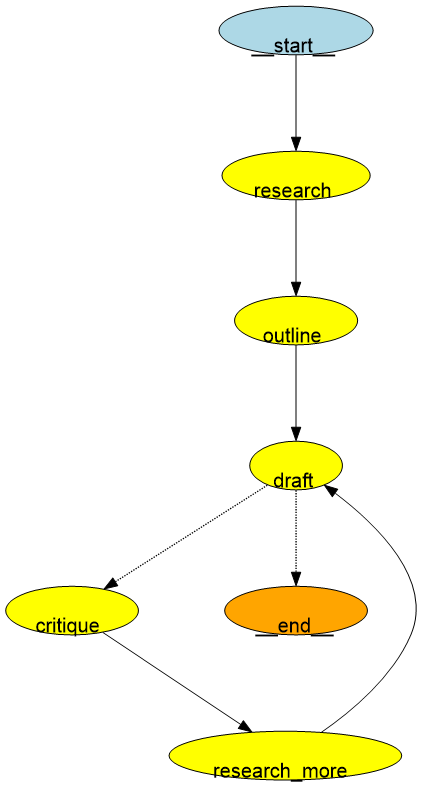

In [13]:
from IPython.display import Image

memory = InMemorySaver()
agent = Agent(model, memory)
agent_graph = agent.get_agent_graph()
Image(agent_graph.get_graph().draw_png())

In [15]:
thread = {"configurable": {"thread_id": "1"}}
start_state = State(
    original_prompt= "what is the difference between langchain and langsmith",
    max_rewrites= 2,
    rewrites =1,
)
final_state = agent_graph.invoke(start_state, thread)


print(f"Final Result: {final_state.draft}")



AttributeError: 'dict' object has no attribute 'final_result'

In [18]:
print(final_state.keys())

dict_keys(['original_prompt', 'context_db', 'research_content', 'critique_db', 'outline', 'draft', 'critique', 'critique_method', 'memory', 'rewrites', 'max_rewrites'])


In [19]:
print(final_state["draft"])

**Podcast Episode Draft: "The Impact of Technology on Daily Life"**

---

**[INTRO MUSIC FADES IN]**

**HOST:**  
Welcome back to *Tech Talk Today*, where we explore the intersection of technology and our everyday lives. I’m your host, [Your Name], and today we’re diving into a topic that affects each and every one of us: the impact of technology on daily life. 

**[INTRO MUSIC FADES OUT]**

**HOST:**  
From the moment we wake up to the sound of our smartphones buzzing with notifications, to the way we unwind at night with streaming services, technology is woven into the fabric of our daily routines. But what does this mean for us as individuals and as a society? 

**[SOUND EFFECT: ALARM CLOCK BUZZING]**

**HOST:**  
Let’s start with the morning. Picture this: your alarm goes off, and before you even get out of bed, you’re scrolling through social media. Studies


In [20]:
print(final_state["critique"])

**Critique of the Draft:**

1. **Accuracy of Information:**
   - The draft does not provide specific data or examples to support the claims about technology's impact on daily life. While the general statements about technology being integrated into our routines are accurate, the lack of concrete examples or statistics makes the discussion feel somewhat superficial.
   - The mention of smartphones and notifications is relevant, but it could benefit from a deeper exploration of how these technologies affect mental health, productivity, and social interactions.

2. **Engagement of the Conversation/Writing:**
   - The introduction is engaging and sets a relatable tone, which is great for drawing in listeners. However, it could be enhanced by including a personal anecdote or a thought-provoking question to stimulate curiosity.
   - The use of sound effects, like the phone notification, adds a nice touch, but the draft could incorporate more varied audio elements or guest interviews to creat

In [30]:
state = State(
    original_prompt= "what is the difference between langchain and langsmith",
    max_rewrites= 2,
    rewrites =1,
)

In [32]:
state["original_prompt"]

'what is the difference between langchain and langsmith'